In [266]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib

from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    davies_bouldin_score,
    calinski_harabasz_score
)

import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from scipy.spatial.distance import cdist
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize']   = (14, 5)
plt.rcParams['axes.titlesize']   = 13
plt.rcParams['axes.titleweight'] = 'bold'

print('Libraries loaded!')

Libraries loaded!


In [267]:
# STEP 1 - Load Processed Data (Member 1 pipeline)
df = pd.read_csv("CC GENERAL.csv")

# Imputation
df.dropna(subset=['CREDIT_LIMIT'], inplace=True)
df.loc[df['MINIMUM_PAYMENTS'].isna() & (df['BALANCE'] == 0), 'MINIMUM_PAYMENTS'] = 0
ratio = (df.loc[df['MINIMUM_PAYMENTS'].notnull(), 'MINIMUM_PAYMENTS'].median() /
         df.loc[df['BALANCE'].notnull(), 'BALANCE'].median())
mask = df['MINIMUM_PAYMENTS'].isna() & (df['BALANCE'] > 0)
df.loc[mask, 'MINIMUM_PAYMENTS'] = ratio * df.loc[mask, 'BALANCE']

# Feature Engineering
df['TOTAL_SPEND']        = df['PURCHASES'] + df['CASH_ADVANCE']
df['CREDIT_UTILIZATION'] = df['BALANCE']   / (df['CREDIT_LIMIT'] + 1)
df['CASH_DEPENDENCY']    = df['CASH_ADVANCE'] / (df['TOTAL_SPEND'] + 1)
df['PAYMENT_EFFICIENCY'] = df['PAYMENTS']  / (df['BALANCE'] + 1)
df['PURCHASE_INTENSITY'] = df['PURCHASES'] / (df['TENURE']  + 1)
df['INSTALLMENT_RATIO']  = df['INSTALLMENTS_PURCHASES'] / (df['PURCHASES'] + 1)
df['ONEOFF_RATIO']       = df['ONEOFF_PURCHASES'] / (df['PURCHASES'] + 1)
df['IS_ACTIVE']          = ((df['PURCHASES'] > 0) | (df['CASH_ADVANCE'] > 0)).astype(int)
df['IS_INACTIVE']        = ((df['PURCHASES'] == 0) & (df['CASH_ADVANCE'] == 0)).astype(int)
df['IS_FULL_PAYER']      = (df['PRC_FULL_PAYMENT'] > 0.5).astype(int)
df['DEBT_PRESSURE']      = df['MINIMUM_PAYMENTS'] / (df['BALANCE'] + 1)
df['TOTAL_TRANSACTIONS'] = df['PURCHASES_TRX'] + df['CASH_ADVANCE_TRX']
df['uses_cash_advance']  = (df['CASH_ADVANCE'] > 0).astype(int)
df.replace([np.inf, -np.inf], 0, inplace=True)
df.fillna(0, inplace=True)

df_model = df.drop(columns=['CUST_ID'])

# Log Transform + Scaling + PCA
X_log    = np.log1p(df_model)
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_log)
X_scaled = pd.DataFrame(X_scaled, columns=df_model.columns)

pca_90   = PCA(n_components=0.9, random_state=42)
X_pca    = pca_90.fit_transform(X_scaled)

pca_2d   = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

print('Processed data ready')
print(f'  Customers : {X_pca.shape[0]:,}')
print(f'  Features  : {X_pca.shape[1]} (after PCA 90%)')

Processed data ready
  Customers : 8,949
  Features  : 10 (after PCA 90%)


Running Elbow Method...
  k= 2  inertia=181,676.69
  k= 3  inertia=151,644.01
  k= 4  inertia=133,706.23
  k= 5  inertia=117,954.80
  k= 6  inertia=105,110.53
  k= 7  inertia=96,440.35
  k= 8  inertia=88,543.81
  k= 9  inertia=83,007.42
  k=10  inertia=77,783.37

Elbow detected at k = 3


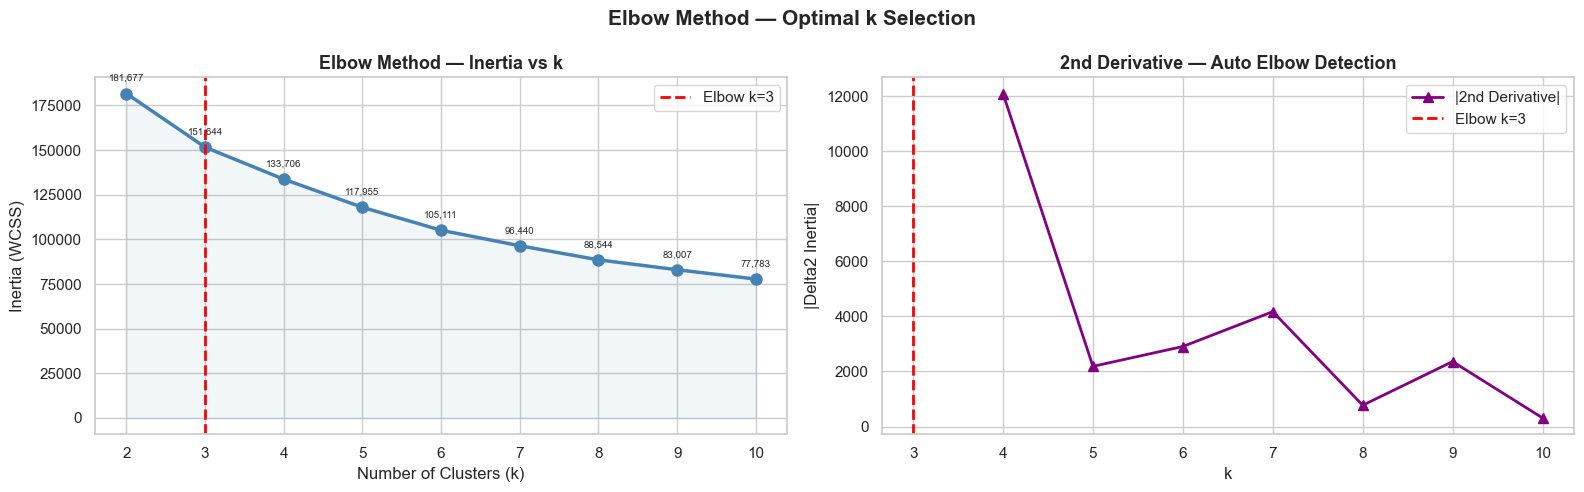

In [268]:
#  Elbow Method (k = 2 to 10)
print('Running Elbow Method...')

K_range = range(2, 11)
wcss    = []

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=20,
                max_iter=500, random_state=42)
    km.fit(X_pca)
    wcss.append(km.inertia_)
    print(f'  k={k:2d}  inertia={km.inertia_:,.2f}')

# Auto-detect elbow via 2nd derivative
wcss_arr    = np.array(wcss)
second_diff = np.diff(np.diff(wcss_arr))
elbow_k     = list(K_range)[np.argmax(np.abs(second_diff)) + 1]
print(f'\nElbow detected at k = {elbow_k}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(list(K_range), wcss, 'o-', color='steelblue', linewidth=2.5, markersize=8)
axes[0].axvline(elbow_k, color='red', linestyle='--', linewidth=2, label=f'Elbow k={elbow_k}')
axes[0].fill_between(list(K_range), wcss, alpha=0.07, color='steelblue')
for k, w in zip(K_range, wcss):
    axes[0].annotate(f'{w:,.0f}', (k, w), textcoords='offset points',
                     xytext=(0, 9), ha='center', fontsize=7)
axes[0].set_title('Elbow Method — Inertia vs k')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].legend()

axes[1].plot(list(K_range)[2:], np.abs(second_diff), '^-',
             color='purple', linewidth=2, markersize=7, label='|2nd Derivative|')
axes[1].axvline(elbow_k, color='red', linestyle='--', linewidth=2, label=f'Elbow k={elbow_k}')
axes[1].set_title('2nd Derivative — Auto Elbow Detection')
axes[1].set_xlabel('k'); axes[1].set_ylabel('|Delta2 Inertia|')
axes[1].legend()

plt.suptitle('Elbow Method — Optimal k Selection', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [269]:
#  KMeans Implementation + Baseline Silhouette Score
final_k = elbow_k if elbow_k >= 3 else 3
if elbow_k < 3:
    print(f'k overridden from {elbow_k} to 3 for richer segmentation')

print(f'Final k = {final_k}')

kmeans = KMeans(n_clusters=final_k, init='k-means++',
                n_init=50, max_iter=1000, random_state=42)
labels = kmeans.fit_predict(X_pca)

# Baseline Silhouette Score
baseline_sil = silhouette_score(X_pca, labels)

print()
print('=' * 50)
print('  BASELINE SILHOUETTE SCORE')
print('=' * 50)
print(f'  KMeans Silhouette : {baseline_sil:.4f}')
print('  All other models (DBSCAN, GMM, DEC)')
print('  will compare against this score')
print('=' * 50)

Final k = 3

  BASELINE SILHOUETTE SCORE
  KMeans Silhouette : 0.2598
  All other models (DBSCAN, GMM, DEC)
  will compare against this score


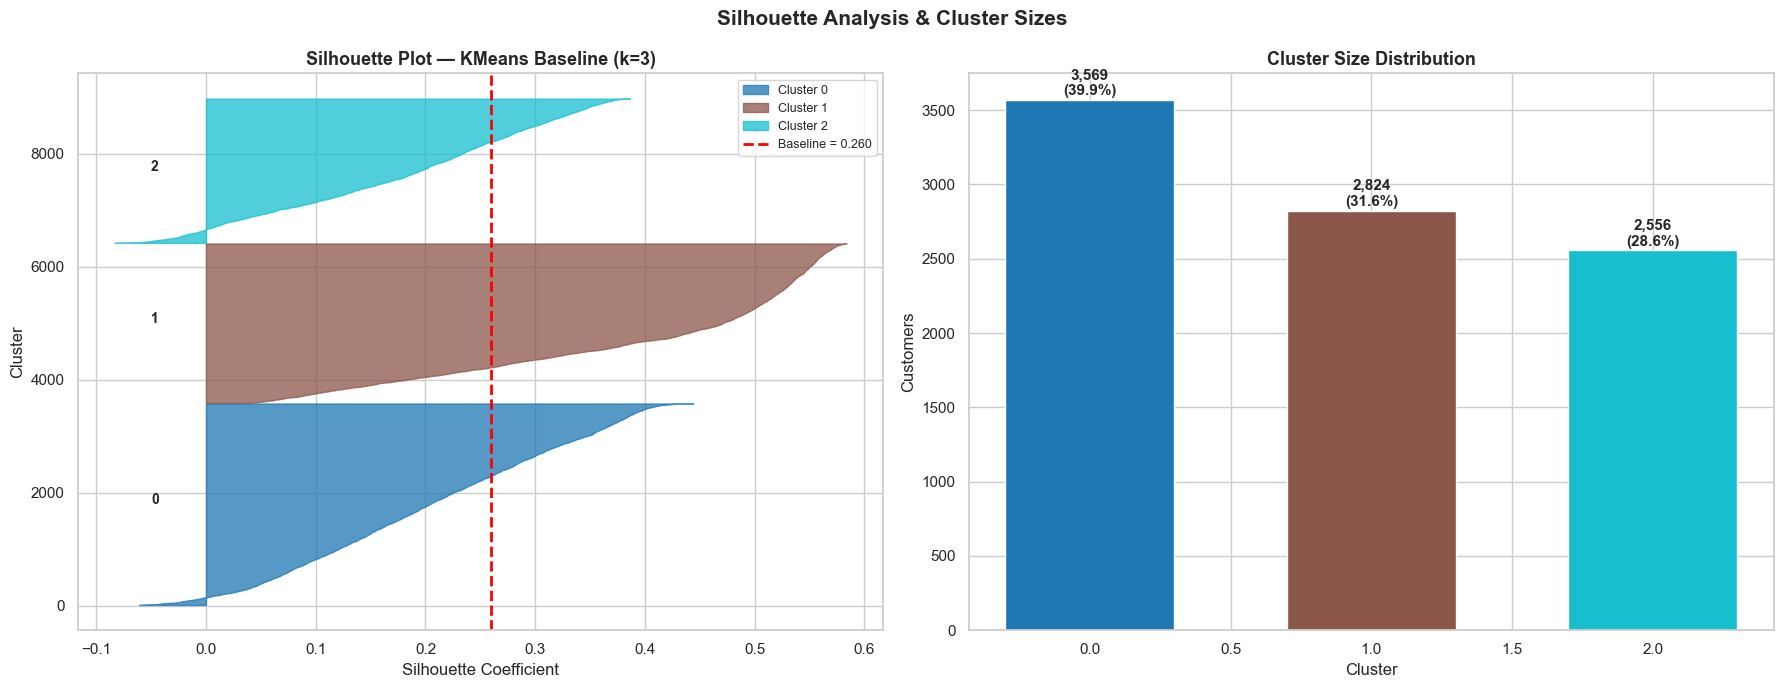


  Cluster Distribution:
  --------------------------------------
  Cluster      Customers    Percentage
  --------------------------------------
  0            3,569        39.9%
  1            2,824        31.6%
  2            2,556        28.6%
  --------------------------------------
  Total        8,949        100.0%


In [270]:
#  - Silhouette Plot + Cluster Size Distribution
sample_sil = silhouette_samples(X_pca, labels)
cmap       = plt.cm.get_cmap('tab10', final_k)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

y_lower = 10
for i in range(final_k):
    vals    = np.sort(sample_sil[labels == i])
    y_upper = y_lower + len(vals)
    axes[0].fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                          alpha=0.75, color=cmap(i), label=f'Cluster {i}')
    axes[0].text(-0.05, y_lower + len(vals)/2, str(i), fontsize=10, fontweight='bold')
    y_lower = y_upper + 10

axes[0].axvline(baseline_sil, color='red', linestyle='--', linewidth=2,
                label=f'Baseline = {baseline_sil:.3f}')
axes[0].set_title(f'Silhouette Plot — KMeans Baseline (k={final_k})')
axes[0].set_xlabel('Silhouette Coefficient')
axes[0].set_ylabel('Cluster')
axes[0].legend(fontsize=9)

sizes = pd.Series(labels).value_counts().sort_index()
bars  = axes[1].bar(sizes.index, sizes.values,
                    color=[cmap(i) for i in range(final_k)],
                    edgecolor='white', width=0.6)
for bar, val in zip(bars, sizes.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}\n({val/len(labels)*100:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Cluster Size Distribution')
axes[1].set_xlabel('Cluster'); axes[1].set_ylabel('Customers')

plt.suptitle('Silhouette Analysis & Cluster Sizes', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Distribution table
print('\n  Cluster Distribution:')
print('  ' + '-'*38)
print(f'  Cluster      Customers    Percentage')
print('  ' + '-'*38)
dist = pd.Series(labels).value_counts().sort_index()
for cid, count in dist.items():
    print(f'  {cid:<12} {count:<12,} {count/len(labels)*100:.1f}%')
print('  ' + '-'*38)
print(f'  Total        {len(labels):<12,} 100.0%')

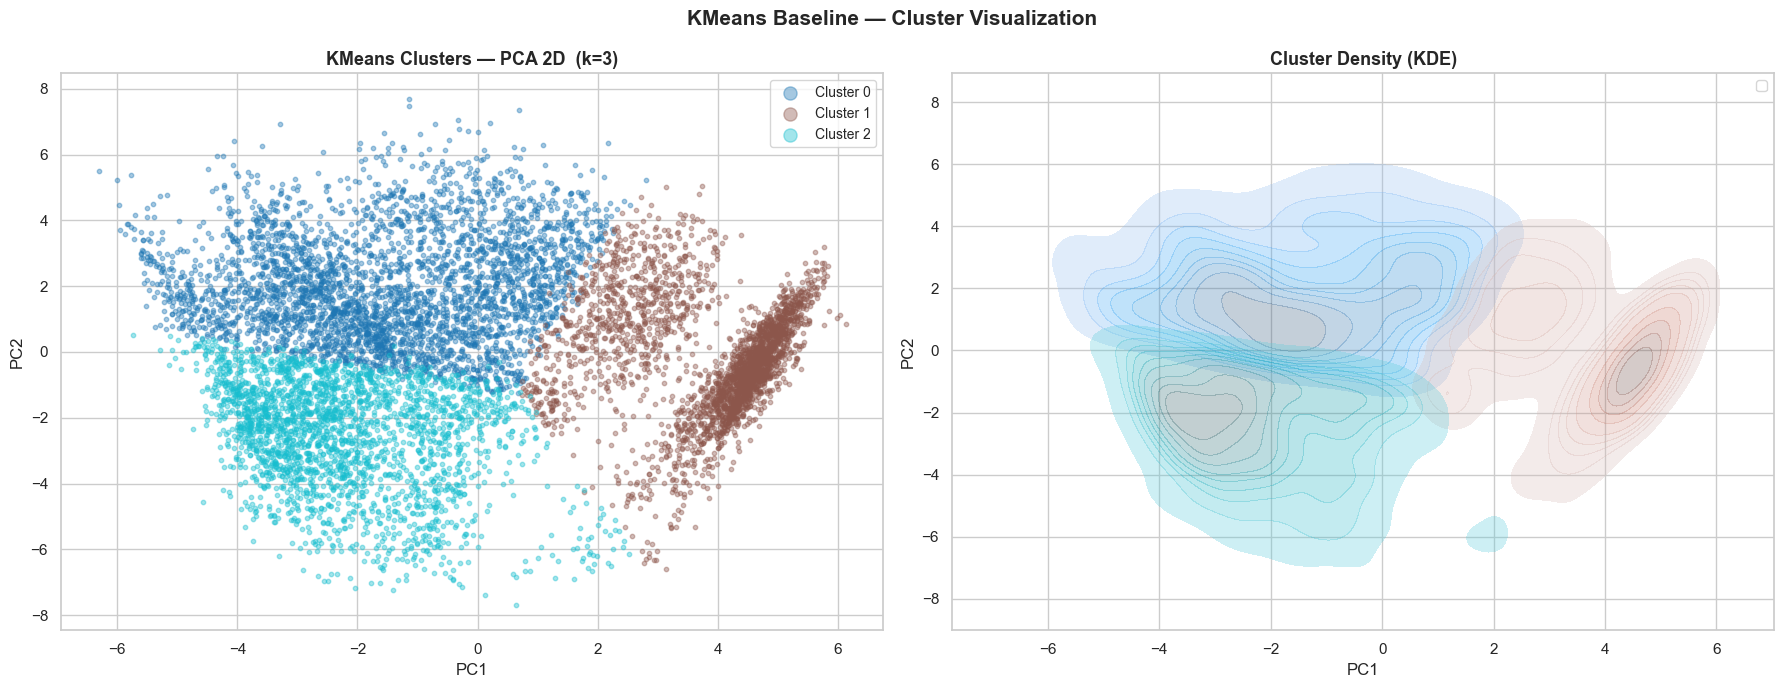

In [271]:
# STEP 5 - PCA Cluster Visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for i in range(final_k):
    mask = labels == i
    axes[0].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                    s=10, alpha=0.4, color=cmap(i), label=f'Cluster {i}')

axes[0].set_title(f'KMeans Clusters — PCA 2D  (k={final_k})')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(markerscale=3, fontsize=10)

for i in range(final_k):
    mask = labels == i
    sns.kdeplot(x=X_pca_2d[mask, 0], y=X_pca_2d[mask, 1],
                ax=axes[1], fill=True, alpha=0.3,
                color=cmap(i), label=f'Cluster {i}')
axes[1].set_title('Cluster Density (KDE)')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend(fontsize=10)

plt.suptitle('KMeans Baseline — Cluster Visualization', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


 Computing evaluation metrics...
  k= 2  Silhouette=0.2807  DB=1.4466  CH=3201.9
  k= 3  Silhouette=0.2565  DB=1.5175  CH=2803.7
  k= 4  Silhouette=0.2627  DB=1.1405  CH=2519.7
  k= 5  Silhouette=0.2368  DB=1.2569  CH=2440.4
  k= 6  Silhouette=0.2529  DB=1.1588  CH=2409.2
  k= 7  Silhouette=0.2504  DB=1.1430  CH=2321.9
  k= 8  Silhouette=0.2445  DB=1.1301  CH=2281.4
  k= 9  Silhouette=0.2572  DB=1.1178  CH=2203.7
  k=10  Silhouette=0.2539  DB=1.1822  CH=2156.8

 Best k — Silhouette        : 2  (0.2807)
 Best k — Davies-Bouldin   : 9  (1.1178)
 Best k — Calinski-Harabasz: 2  (3201.9)


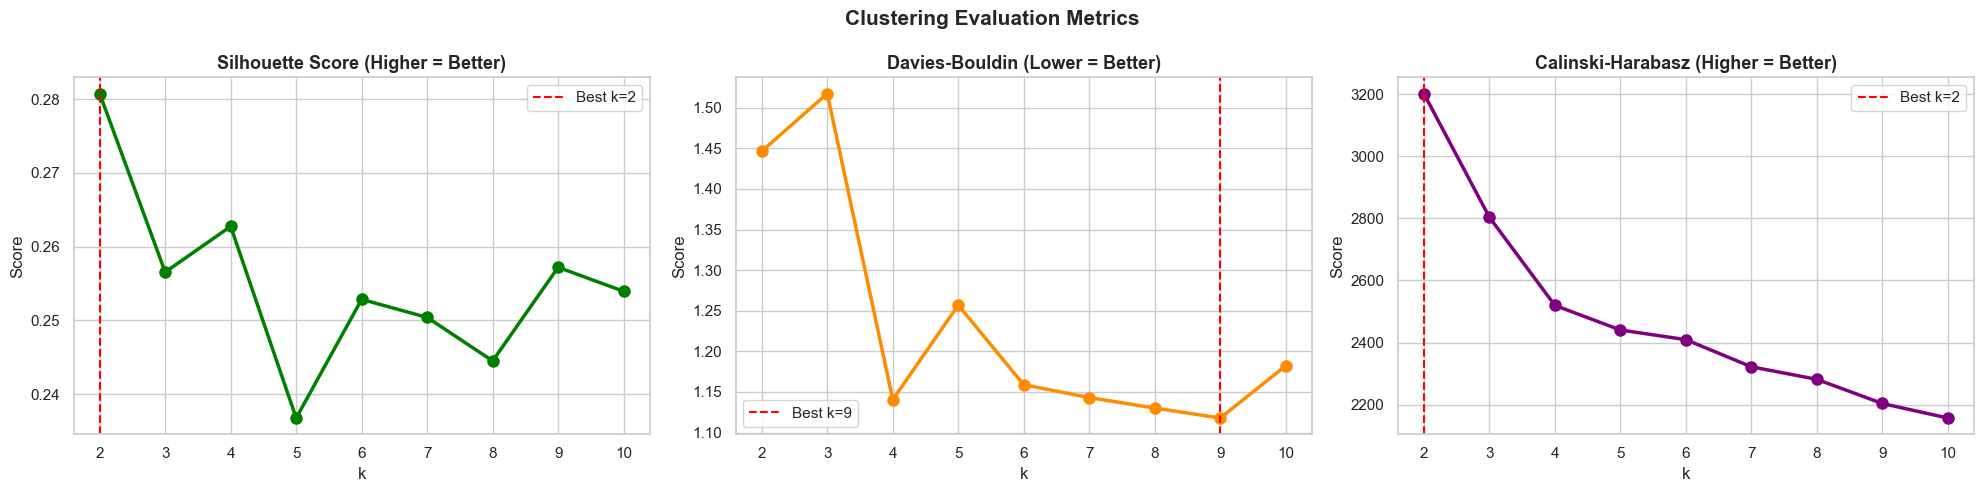

In [272]:
# STEP 3: Evaluation Metrics — Silhouette + DB + CH
# ================================================================
print("\n Computing evaluation metrics...")

sil_scores = []
db_scores  = []
ch_scores  = []

for k in K_range:
    km     = KMeans(n_clusters=k, init='k-means++', n_init=20, 
                    max_iter=500, random_state=42)
    labels = km.fit_predict(X_pca)
    
    
    score = silhouette_score(X_pca, labels, sample_size=1000, random_state=42)
    sil_scores.append(score)
    
    db_scores.append(davies_bouldin_score(X_pca, labels))
    ch_scores.append(calinski_harabasz_score(X_pca, labels))
    
    print(f"  k={k:2d}  Silhouette={sil_scores[-1]:.4f}  "
          f"DB={db_scores[-1]:.4f}  CH={ch_scores[-1]:.1f}")

best_sil_k = list(K_range)[np.argmax(sil_scores)]
best_db_k  = list(K_range)[np.argmin(db_scores)]
best_ch_k  = list(K_range)[np.argmax(ch_scores)]

print(f"\n Best k — Silhouette        : {best_sil_k}  ({max(sil_scores):.4f})")
print(f" Best k — Davies-Bouldin   : {best_db_k}  ({min(db_scores):.4f})")
print(f" Best k — Calinski-Harabasz: {best_ch_k}  ({max(ch_scores):.1f})")

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].plot(list(K_range), sil_scores, 'o-', color='green', linewidth=2.5, markersize=8)
axes[0].axvline(best_sil_k, color='red', linestyle='--', label=f'Best k={best_sil_k}')
axes[0].set_title('Silhouette Score (Higher = Better)')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Score'); axes[0].legend()

axes[1].plot(list(K_range), db_scores, 'o-', color='darkorange', linewidth=2.5, markersize=8)
axes[1].axvline(best_db_k, color='red', linestyle='--', label=f'Best k={best_db_k}')
axes[1].set_title('Davies-Bouldin (Lower = Better)')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Score'); axes[1].legend()

axes[2].plot(list(K_range), ch_scores, 'o-', color='purple', linewidth=2.5, markersize=8)
axes[2].axvline(best_ch_k, color='red', linestyle='--', label=f'Best k={best_ch_k}')
axes[2].set_title('Calinski-Harabasz (Higher = Better)')
axes[2].set_xlabel('k'); axes[2].set_ylabel('Score'); axes[2].legend()

plt.suptitle('Clustering Evaluation Metrics', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

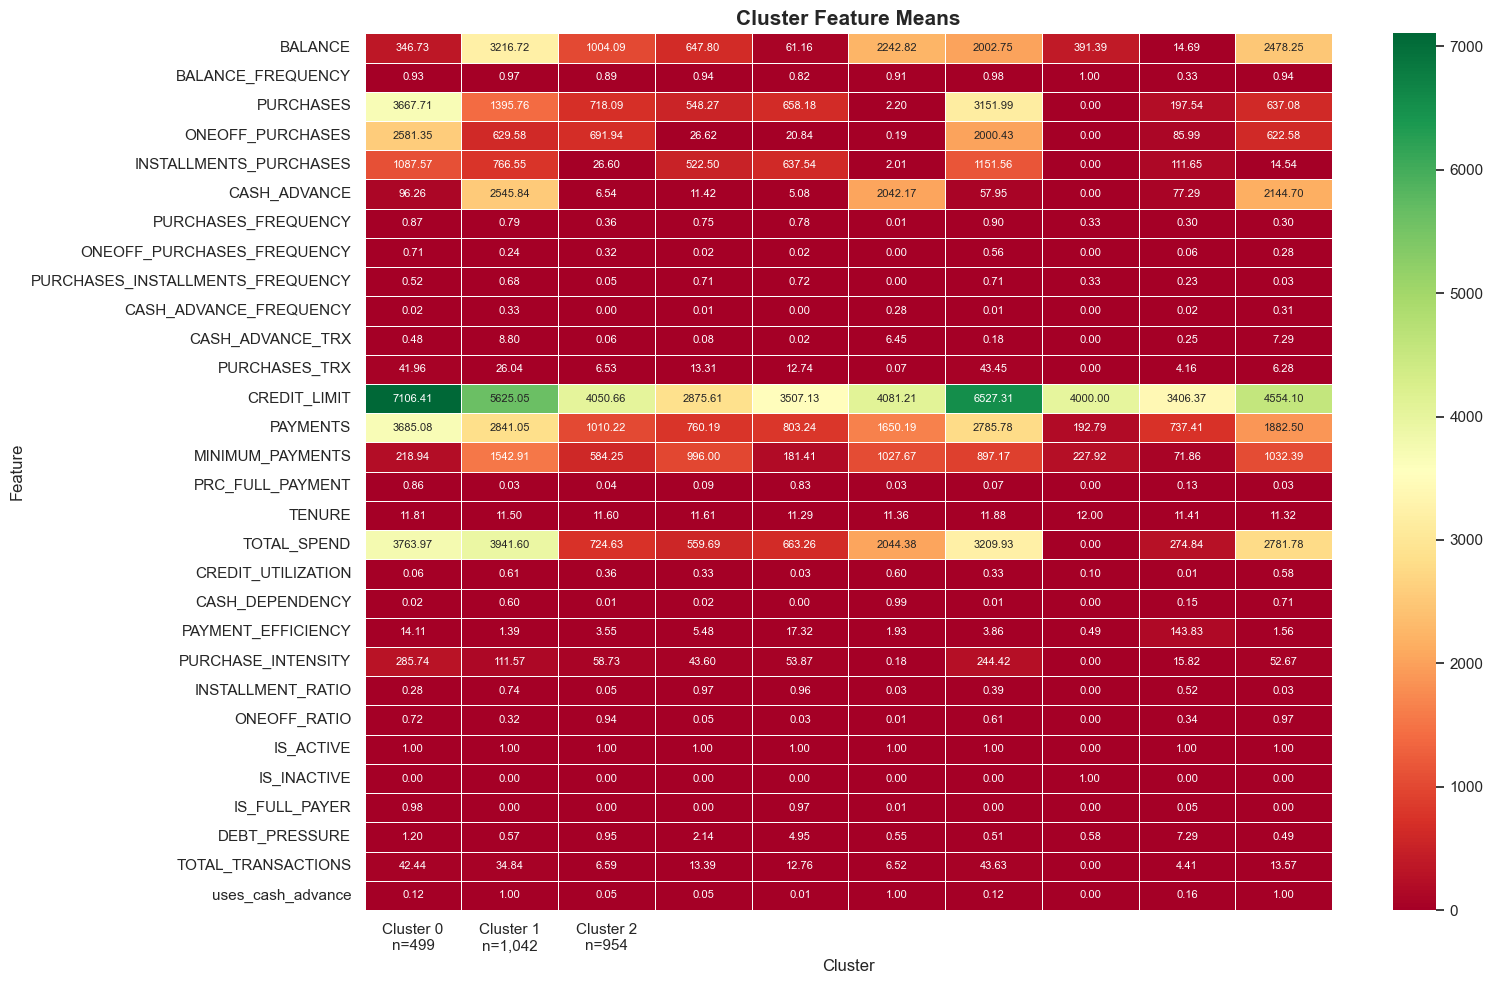


INITIAL CLUSTER INTERPRETATION:

  Cluster 0  (499 customers — 5.6%)
    Balance            : 346.73
    Purchases          : 3667.71
    Cash Advance       : 96.26
    Credit Utilization : 0.06
    Payment Efficiency : 14.11
    Debt Pressure      : 1.20
    Active %           : 100.0%
    Full Payers %      : 97.6%

  Cluster 1  (1,042 customers — 11.6%)
    Balance            : 3216.72
    Purchases          : 1395.76
    Cash Advance       : 2545.84
    Credit Utilization : 0.61
    Payment Efficiency : 1.39
    Debt Pressure      : 0.57
    Active %           : 100.0%
    Full Payers %      : 0.4%

  Cluster 2  (954 customers — 10.7%)
    Balance            : 1004.09
    Purchases          : 718.09
    Cash Advance       : 6.54
    Credit Utilization : 0.36
    Payment Efficiency : 3.55
    Debt Pressure      : 0.95
    Active %           : 100.0%
    Full Payers %      : 0.0%


In [273]:
#  - Initial Cluster Interpretation
df_profile           = df_model.copy()
df_profile['Cluster']= labels
cluster_means        = df_profile.groupby('Cluster').mean()
cluster_count        = df_profile.groupby('Cluster').size()

plt.figure(figsize=(16, 10))
sns.heatmap(
    cluster_means.T, annot=True, fmt='.2f', cmap='RdYlGn',
    linewidths=0.5, annot_kws={'size': 8},
    xticklabels=[f'Cluster {i}\nn={cluster_count[i]:,}' for i in range(final_k)]
)
plt.title('Cluster Feature Means', fontsize=15, fontweight='bold')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print('\nINITIAL CLUSTER INTERPRETATION:')
print('=' * 55)
key_feats = ['BALANCE','PURCHASES','CASH_ADVANCE',
             'CREDIT_UTILIZATION','PAYMENT_EFFICIENCY',
             'DEBT_PRESSURE','IS_ACTIVE','IS_FULL_PAYER']
for i in range(final_k):
    row = cluster_means.loc[i, key_feats]
    print(f'\n  Cluster {i}  ({cluster_count[i]:,} customers — {cluster_count[i]/len(labels)*100:.1f}%)')
    print(f'    Balance            : {row["BALANCE"]:.2f}')
    print(f'    Purchases          : {row["PURCHASES"]:.2f}')
    print(f'    Cash Advance       : {row["CASH_ADVANCE"]:.2f}')
    print(f'    Credit Utilization : {row["CREDIT_UTILIZATION"]:.2f}')
    print(f'    Payment Efficiency : {row["PAYMENT_EFFICIENCY"]:.2f}')
    print(f'    Debt Pressure      : {row["DEBT_PRESSURE"]:.2f}')
    print(f'    Active %           : {row["IS_ACTIVE"]*100:.1f}%')
    print(f'    Full Payers %      : {row["IS_FULL_PAYER"]*100:.1f}%')
print('=' * 55)

In [274]:
#  - Save Outputs
joblib.dump(kmeans, 'kmeans_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(pca_90, 'pca_model.pkl')

# kmeans_labels.csv — cluster assignment per customer
labels_df = pd.DataFrame({
    'CUST_ID'       : df['CUST_ID'].values,
    'KMeans_Cluster': labels
})
labels_df.to_csv('kmeans_labels.csv', index=False)

# Full data with cluster label
df_out           = df.copy()
df_out['Cluster']= labels
df_out.to_csv('data_with_kmeans.csv', index=False)

print('\n' + '='*60)
print('  TASK 2 COMPLETE — KMeans Baseline')
print('='*60)
print('  Saved:')
print('    kmeans_model.pkl     -> for UI & comparison')
print('    kmeans_labels.csv    -> cluster per customer')
print('    scaler.pkl           -> for UI prediction')
print('    pca_model.pkl        -> for UI prediction')
print('    data_with_kmeans.csv -> full data + labels')
print()
print(f'  Final k       : {final_k}')
print(f'  Baseline Sil. : {baseline_sil:.4f}  <- target to beat')
print()
print('  Comparison targets:')
print(f'    DBSCAN  Silhouette > {baseline_sil:.4f} to outperform baseline')
print(f'    GMM     Silhouette > {baseline_sil:.4f} to outperform baseline')
print(f'    DEC     Silhouette > {baseline_sil:.4f} to outperform baseline')
print()
for i in range(final_k):
    n = (labels == i).sum()
    print(f'  Cluster {i} : {n:,} customers ({n/len(labels)*100:.1f}%)')
print('='*60)



  TASK 2 COMPLETE — KMeans Baseline
  Saved:
    kmeans_model.pkl     -> for UI & comparison
    kmeans_labels.csv    -> cluster per customer
    scaler.pkl           -> for UI prediction
    pca_model.pkl        -> for UI prediction
    data_with_kmeans.csv -> full data + labels

  Final k       : 3
  Baseline Sil. : 0.2598  <- target to beat

  Comparison targets:
    DBSCAN  Silhouette > 0.2598 to outperform baseline
    GMM     Silhouette > 0.2598 to outperform baseline
    DEC     Silhouette > 0.2598 to outperform baseline

  Cluster 0 : 499 customers (5.6%)
  Cluster 1 : 1,042 customers (11.6%)
  Cluster 2 : 954 customers (10.7%)


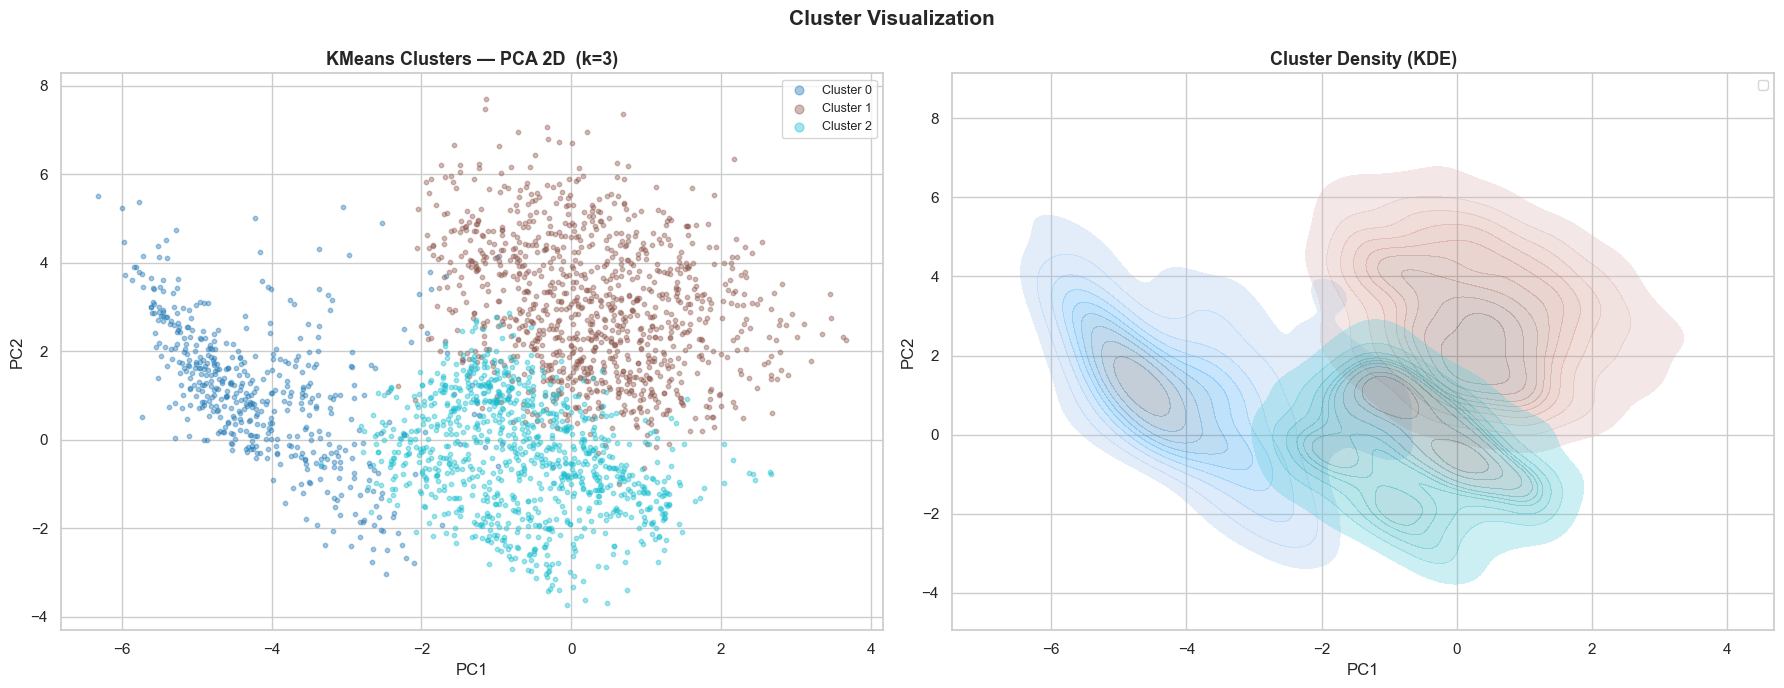

In [275]:
#  STEP 6: Cluster Visualization — PCA 2D
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
 
for i in range(final_k):
    mask = labels == i
    axes[0].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                    s=10, alpha=0.4, color=cmap(i), label=f'Cluster {i}')
 
axes[0].set_title(f'KMeans Clusters — PCA 2D  (k={final_k})')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(markerscale=2, fontsize=9)
 
for i in range(final_k):
    mask = labels == i
    sns.kdeplot(x=X_pca_2d[mask, 0], y=X_pca_2d[mask, 1],
                ax=axes[1], fill=True, alpha=0.3,
                color=cmap(i), label=f'Cluster {i}')
axes[1].set_title('Cluster Density (KDE)')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend(fontsize=9)
 
plt.suptitle('Cluster Visualization', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


 CLUSTER PROFILES:
Cluster                                  0         1         2         3         4         5         6         7         8         9
BALANCE                            346.727  3216.723  1004.085   647.797    61.164  2242.816  2002.755   391.385    14.694  2478.249
BALANCE_FREQUENCY                    0.926     0.975     0.888     0.936     0.820     0.914     0.976     1.000     0.328     0.944
PURCHASES                         3667.711  1395.763   718.095   548.269   658.180     2.204  3151.987     0.000   197.541   637.076
ONEOFF_PURCHASES                  2581.347   629.582   691.943    26.621    20.843     0.193  2000.427     0.000    85.986   622.577
INSTALLMENTS_PURCHASES            1087.567   766.553    26.601   522.502   637.537     2.011  1151.560     0.000   111.649    14.541
CASH_ADVANCE                        96.260  2545.839     6.537    11.418     5.081  2042.172    57.945     0.000    77.294  2144.699
PURCHASES_FREQUENCY                  0.874     0.

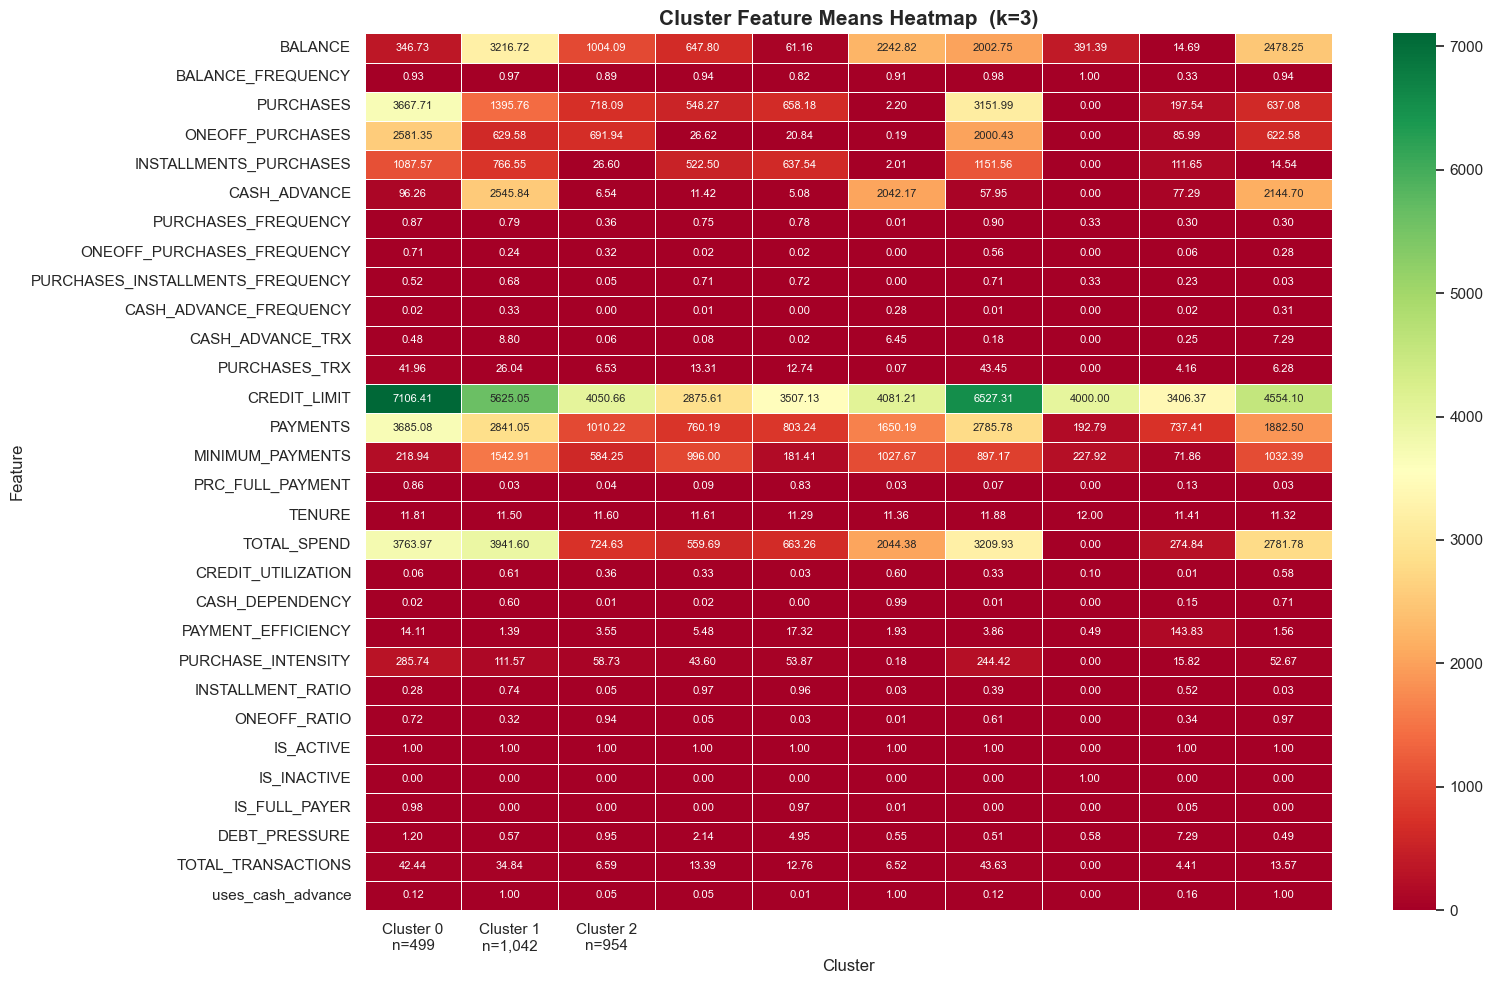

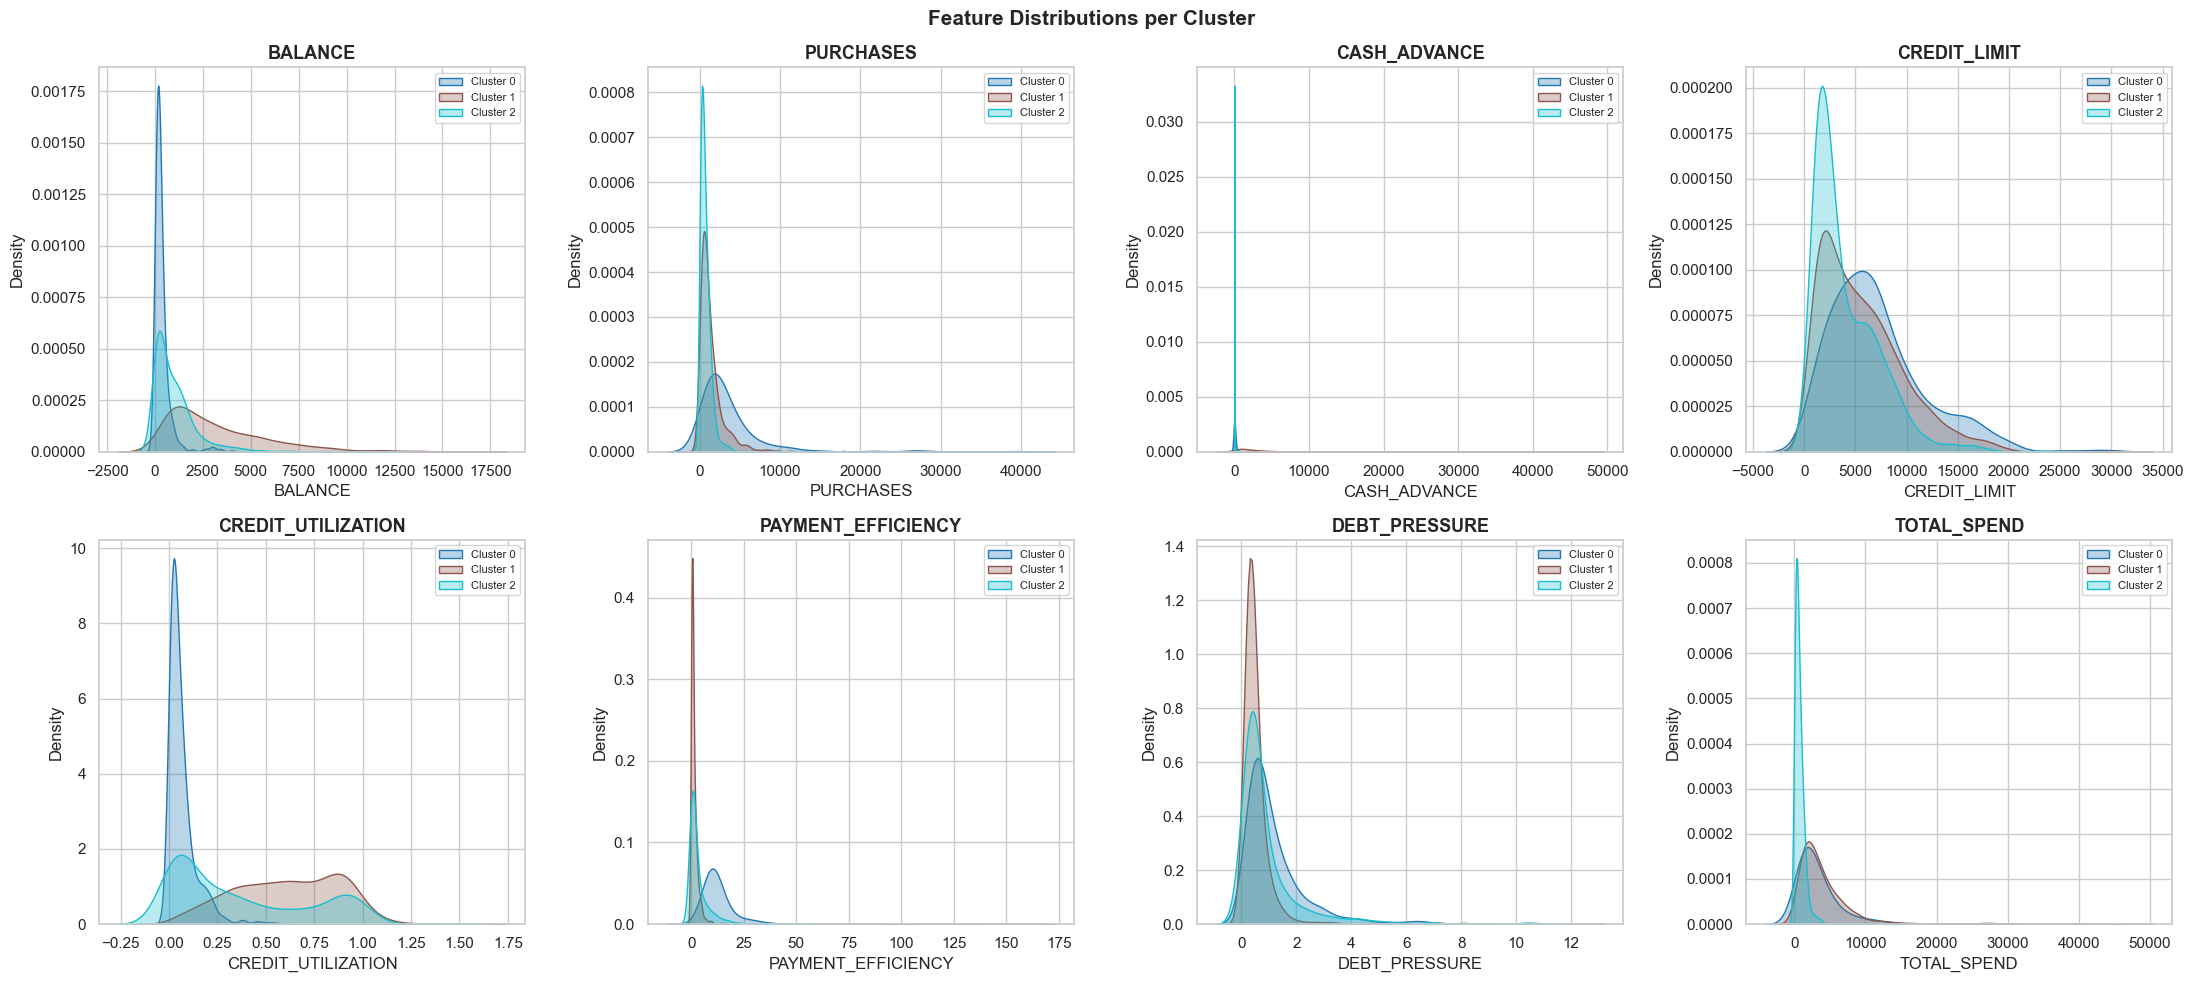

In [276]:
#  STEP 7: Cluster Profiling — Heatmap + KDE
# ================================================================
df_profile            = df_model.copy()
df_profile['Cluster'] = labels
cluster_means         = df_profile.groupby('Cluster').mean()
cluster_count         = df_profile.groupby('Cluster').size()
 
print("\n CLUSTER PROFILES:")
print(cluster_means.T.round(3).to_string())
 
plt.figure(figsize=(16, 10))
sns.heatmap(
    cluster_means.T, annot=True, fmt='.2f', cmap='RdYlGn',
    linewidths=0.5, annot_kws={'size': 8},
    xticklabels=[f'Cluster {i}\nn={cluster_count[i]:,}'
                 for i in range(final_k)]
)
plt.title(f'Cluster Feature Means Heatmap  (k={final_k})',
          fontsize=15, fontweight='bold')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()
 
top_feats = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT',
             'CREDIT_UTILIZATION', 'PAYMENT_EFFICIENCY',
             'DEBT_PRESSURE', 'TOTAL_SPEND']
 
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()
for idx, feat in enumerate(top_feats):
    for i in range(final_k):
        sns.kdeplot(df_profile.loc[labels == i, feat],
                    ax=axes[idx], fill=True, alpha=0.3,
                    color=cmap(i), label=f'Cluster {i}')
    axes[idx].set_title(feat)
    axes[idx].legend(fontsize=8)
 
plt.suptitle('Feature Distributions per Cluster',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

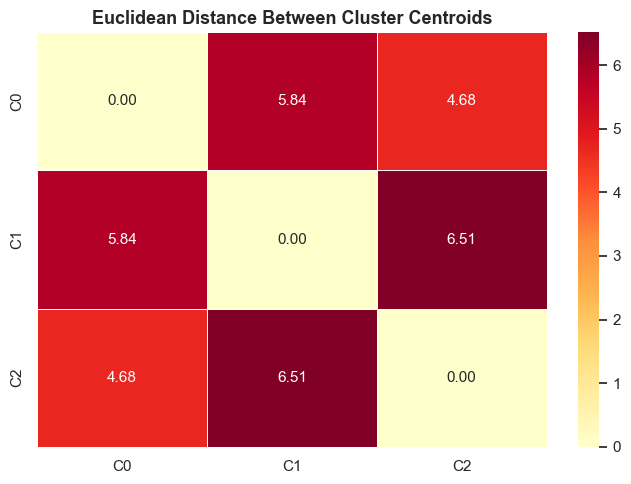

In [277]:
#  STEP 8: Centroid Distance Matrix
# ================================================================
dist_matrix = cdist(kmeans.cluster_centers_,
                     kmeans.cluster_centers_, metric='euclidean')
dist_df     = pd.DataFrame(
    dist_matrix,
    index=[f'C{i}' for i in range(final_k)],
    columns=[f'C{i}' for i in range(final_k)]
)
 
plt.figure(figsize=(7, 5))
sns.heatmap(dist_df, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, annot_kws={'size': 11})
plt.title('Euclidean Distance Between Cluster Centroids', fontweight='bold')
plt.tight_layout()
plt.show()
 

In [278]:
#  STEP 9: Cluster Interpretation
# ================================================================
print("\n CLUSTER INTERPRETATION:")
print("=" * 60)
 
interp_feats = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE',
                'CREDIT_UTILIZATION', 'PAYMENT_EFFICIENCY',
                'DEBT_PRESSURE', 'IS_ACTIVE', 'IS_FULL_PAYER']
 
for i in range(final_k):
    row = cluster_means.loc[i, interp_feats]
    print(f"\n  Cluster {i}  (n={cluster_count[i]:,} — {cluster_count[i]/len(labels)*100:.1f}%)")
    print(f"    Balance             : {row['BALANCE']:.2f}")
    print(f"    Purchases           : {row['PURCHASES']:.2f}")
    print(f"    Cash Advance        : {row['CASH_ADVANCE']:.2f}")
    print(f"    Credit Utilization  : {row['CREDIT_UTILIZATION']:.2f}")
    print(f"    Payment Efficiency  : {row['PAYMENT_EFFICIENCY']:.2f}")
    print(f"    Debt Pressure       : {row['DEBT_PRESSURE']:.2f}")
    print(f"    Active Customers %  : {row['IS_ACTIVE']*100:.1f}%")
    print(f"    Full Payers %       : {row['IS_FULL_PAYER']*100:.1f}%")
 
print("=" * 60)


 CLUSTER INTERPRETATION:

  Cluster 0  (n=499 — 5.6%)
    Balance             : 346.73
    Purchases           : 3667.71
    Cash Advance        : 96.26
    Credit Utilization  : 0.06
    Payment Efficiency  : 14.11
    Debt Pressure       : 1.20
    Active Customers %  : 100.0%
    Full Payers %       : 97.6%

  Cluster 1  (n=1,042 — 11.6%)
    Balance             : 3216.72
    Purchases           : 1395.76
    Cash Advance        : 2545.84
    Credit Utilization  : 0.61
    Payment Efficiency  : 1.39
    Debt Pressure       : 0.57
    Active Customers %  : 100.0%
    Full Payers %       : 0.4%

  Cluster 2  (n=954 — 10.7%)
    Balance             : 1004.09
    Purchases           : 718.09
    Cash Advance        : 6.54
    Credit Utilization  : 0.36
    Payment Efficiency  : 3.55
    Debt Pressure       : 0.95
    Active Customers %  : 100.0%
    Full Payers %       : 0.0%


In [279]:
#  STEP 10: Save
# ================================================================
df_out            = df.copy()
df_out['Cluster'] = labels
df_out.to_csv('data_with_kmeans.csv', index=False)
 
df_scaled_out            = X_scaled.copy()
df_scaled_out['Cluster'] = labels
df_scaled_out.to_csv('data_scaled_with_kmeans.csv', index=False)
 
joblib.dump(kmeans, 'kmeans_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(pca_90, 'pca_model.pkl')
 
print("\n" + "="*60)
print("  TASK 2 COMPLETE — Saved Files:")
print("="*60)
print("    data_with_kmeans.csv")
print("    data_scaled_with_kmeans.csv")
print("    kmeans_model.pkl")
print("    scaler.pkl")
print("    pca_model.pkl")
print()
print(f"  Final k        : {final_k}")
print(f"  Silhouette     : {baseline_sil:.4f}")
print(f"  Davies-Bouldin : {davies_bouldin_score(X_pca, labels):.4f}")
print(f"  Calinski-Harab.: {calinski_harabasz_score(X_pca, labels):.1f}")
print()
for i in range(final_k):
    n = (labels == i).sum()
    print(f"  Cluster {i} : {n:,} customers  ({n/len(labels)*100:.1f}%)")
print("="*60)



  TASK 2 COMPLETE — Saved Files:
    data_with_kmeans.csv
    data_scaled_with_kmeans.csv
    kmeans_model.pkl
    scaler.pkl
    pca_model.pkl

  Final k        : 3
  Silhouette     : 0.2598
  Davies-Bouldin : 1.1822
  Calinski-Harab.: 2156.8

  Cluster 0 : 499 customers  (5.6%)
  Cluster 1 : 1,042 customers  (11.6%)
  Cluster 2 : 954 customers  (10.7%)


In [280]:
X_dbscan = X_scaled.copy()

pca_vis = PCA(n_components=2, random_state=42)
X_vis = pca_vis.fit_transform(X_dbscan)


neighbors = NearestNeighbors(n_neighbors=10)
neighbors_fit = neighbors.fit(X_dbscan)

distances, _ = neighbors_fit.kneighbors(X_dbscan)
distances = np.sort(distances[:, -1])

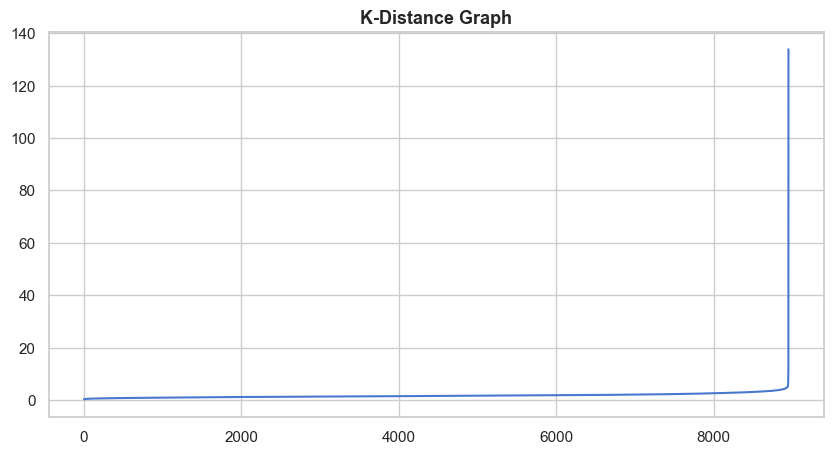

In [281]:
plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.title("K-Distance Graph")
plt.grid(True)
plt.show()

In [345]:
dbscan = DBSCAN(
    eps=2.1,
    min_samples=15
)

dbscan_labels = dbscan.fit_predict(X_dbscan)

In [346]:
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
noise = np.sum(dbscan_labels == -1)
noise_pct = noise / len(dbscan_labels) * 100

print(f"DBSCAN Clusters: {n_clusters}")
print(f"Noise Points: {noise}")
print(f"Noise Percentage: {noise_pct:.2f}%")

DBSCAN Clusters: 5
Noise Points: 1226
Noise Percentage: 13.70%


In [347]:
valid_mask = dbscan_labels != -1

if n_clusters > 1:
    sil = silhouette_score(
        X_dbscan[valid_mask],
        dbscan_labels[valid_mask]
    )

    dbi = davies_bouldin_score(
        X_dbscan[valid_mask],
        dbscan_labels[valid_mask]
    )

    ch = calinski_harabasz_score(
        X_dbscan[valid_mask],
        dbscan_labels[valid_mask]
    )

    print(f"Silhouette: {sil:.4f}")
    print(f"Davies-Bouldin: {dbi:.4f}")
    print(f"Calinski-Harabasz: {ch:.4f}")

Silhouette: 0.2358
Davies-Bouldin: 1.2696
Calinski-Harabasz: 1198.9558


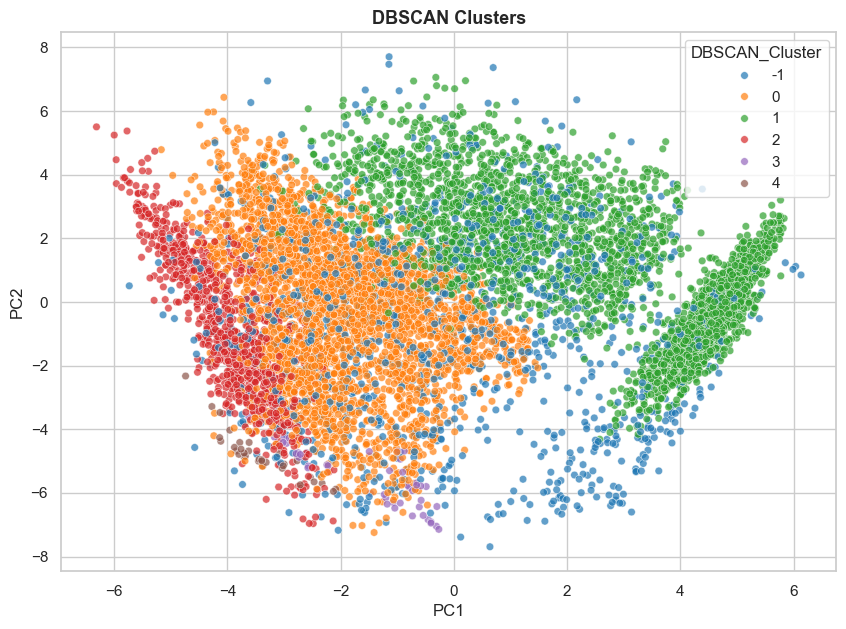

In [285]:
dbscan_df = pd.DataFrame(X_vis, columns=["PC1", "PC2"])
dbscan_df["DBSCAN_Cluster"] = dbscan_labels

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=dbscan_df,
    x="PC1",
    y="PC2",
    hue="DBSCAN_Cluster",
    palette="tab10",
    s=30,
    alpha=0.7
)

plt.title("DBSCAN Clusters")
plt.show()

In [286]:
dbscan_df.to_csv("dbscan_labels.csv", index=False)

print("\nSaved:")
print("- dbscan_labels.csv")


Saved:
- dbscan_labels.csv


In [287]:
print("KMeans Baseline:", baseline_sil)
print("DBSCAN:", db_silhouette)

if db_silhouette > baseline_sil:
    print("DBSCAN outperformed KMeans")
else:
    print("KMeans remains stronger")

KMeans Baseline: 0.2597708681574341
DBSCAN: -0.08712020654685682
KMeans remains stronger


In [288]:

# ================================================================
# GMM + BUSINESS INTELLIGENCE LAYER
# ================================================================

from sklearn.mixture import GaussianMixture

# ================================================================
# STEP 1: Gaussian Mixture Model (GMM)
# ================================================================
print('=' * 70)
print(' Gaussian Mixture Model (GMM)')
print('=' * 70)

# Use same number of clusters as KMeans baseline
n_gmm_clusters = final_k

# Train GMM
# covariance_type='full' gives flexible cluster shapes
# reg_covar avoids singular covariance issues

gmm = GaussianMixture(
    n_components=n_gmm_clusters,
    covariance_type='full',
    n_init=10,
    max_iter=500,
    reg_covar=1e-6,
    random_state=42
)

# Fit model
#gmm.fit(X_pca)

# Predict clusters
gmm_labels = gmm.fit_predict(X_pca)



 Gaussian Mixture Model (GMM)


In [289]:
# ================================================================
# STEP 2: Predict Probabilities (Soft Clustering)
# ================================================================

# Probability of each customer belonging to each cluster
cluster_probabilities = gmm.predict_proba(X_pca)

# Confidence score = highest probability
confidence_scores = cluster_probabilities.max(axis=1)

# ================================================================
# STEP 3: GMM Evaluation
# ================================================================

# Evaluation metrics
gmm_silhouette = silhouette_score(X_pca, gmm_labels)
gmm_dbi        = davies_bouldin_score(X_pca, gmm_labels)
gmm_ch         = calinski_harabasz_score(X_pca, gmm_labels)

print(f'GMM Silhouette Score     : {gmm_silhouette:.4f}')
print(f'GMM Davies-Bouldin Index : {gmm_dbi:.4f}')
print(f'GMM Calinski-Harabasz    : {gmm_ch:.2f}')
print()

# Compare with KMeans
print('=' * 70)
print(' COMPARISON WITH KMEANS')
print('=' * 70)
print(f'KMeans Baseline : {baseline_sil:.4f}')
print(f'GMM             : {gmm_silhouette:.4f}')

if gmm_silhouette > baseline_sil:
    print('\n GMM outperformed KMeans!')
else:
    print('\n KMeans still performs better.')



GMM Silhouette Score     : 0.2024
GMM Davies-Bouldin Index : 2.6124
GMM Calinski-Harabasz    : 1480.22

 COMPARISON WITH KMEANS
KMeans Baseline : 0.2598
GMM             : 0.2024

 KMeans still performs better.


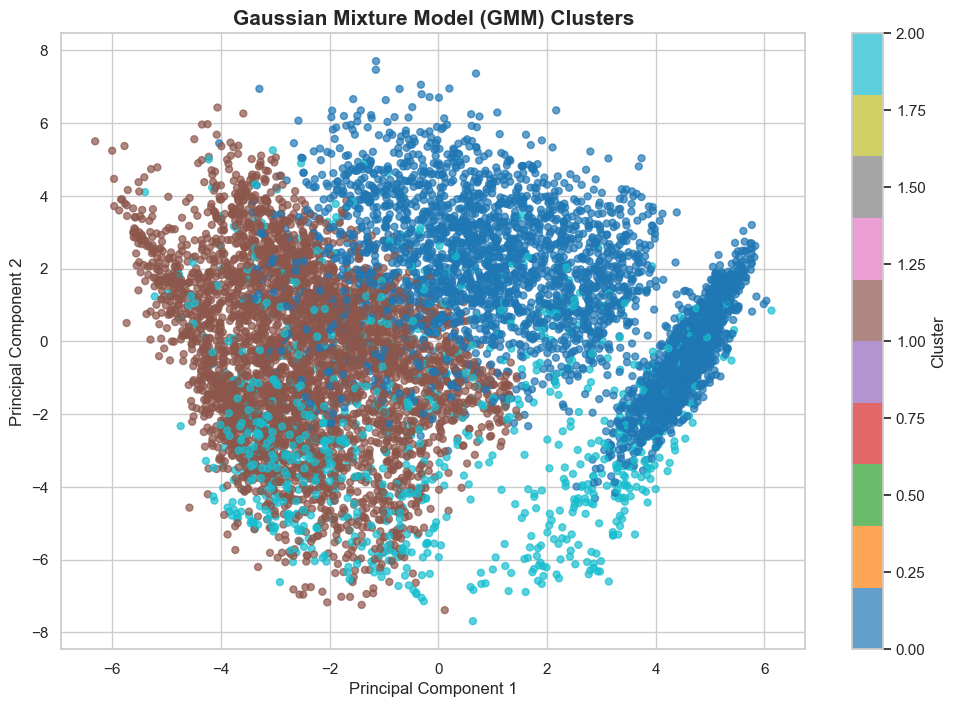

In [290]:
# ================================================================
# STEP 4: GMM Visualization
# ================================================================

plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=gmm_labels,
    cmap='tab10',
    s=25,
    alpha=0.7
)

plt.title('Gaussian Mixture Model (GMM) Clusters', fontsize=15, fontweight='bold')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, label='Cluster')
plt.show()



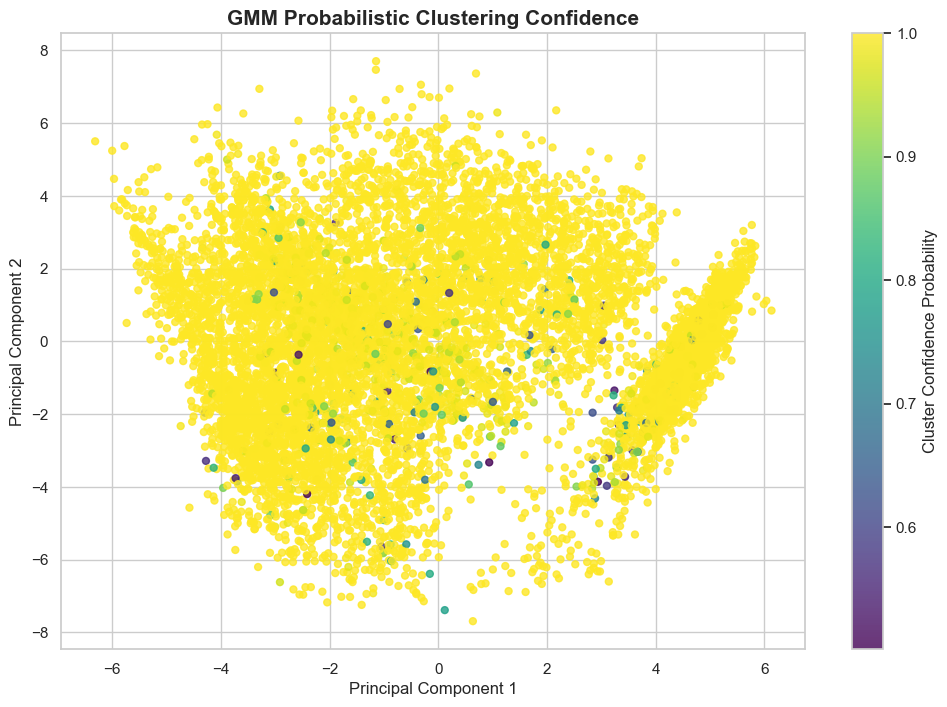

In [291]:
# ================================================================
# STEP 5: Probabilistic Clustering Visualization
# ================================================================

plt.figure(figsize=(12, 8))

# Color intensity based on confidence
plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=confidence_scores,
    cmap='viridis',
    s=25,
    alpha=0.8
)

plt.colorbar(label='Cluster Confidence Probability')
plt.title('GMM Probabilistic Clustering Confidence', fontsize=15, fontweight='bold')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()




In [292]:
# ================================================================
# STEP 6: Create Business Intelligence Layer
# ================================================================

business_df = df.copy()

# Add clustering outputs
business_df['GMM_Cluster'] = gmm_labels
business_df['Cluster_Confidence'] = confidence_scores

# ================================================================
# STEP 7: Cluster Profiling
# ================================================================

cluster_profile = business_df.groupby('GMM_Cluster').agg({
    'BALANCE': 'mean',
    'PURCHASES': 'mean',
    'CREDIT_LIMIT': 'mean',
    'PAYMENTS': 'mean',
    'MINIMUM_PAYMENTS': 'mean',
    'CASH_ADVANCE': 'mean',
    'TENURE': 'mean',
    'PRC_FULL_PAYMENT': 'mean',
    'INSTALLMENTS_PURCHASES': 'mean',
    'PURCHASES_TRX': 'mean',
    'PAYMENT_EFFICIENCY': 'mean',
    'CREDIT_UTILIZATION': 'mean',
    'TOTAL_SPEND': 'mean',
    'CUST_ID': 'count'
}).rename(columns={'CUST_ID': 'CUSTOMER_COUNT'})

print('\n' + '=' * 70)
print(' CLUSTER PROFILE')
print('=' * 70)
print(cluster_profile.round(2))




 CLUSTER PROFILE
             BALANCE  PURCHASES  CREDIT_LIMIT  PAYMENTS  MINIMUM_PAYMENTS  \
GMM_Cluster                                                                 
0            2528.31     653.25       4626.81   2007.49            948.22   
1             859.88    1458.67       4600.06   1553.53            637.60   
2             482.38     639.63       3577.26   1346.86           1194.49   

             CASH_ADVANCE  TENURE  PRC_FULL_PAYMENT  INSTALLMENTS_PURCHASES  \
GMM_Cluster                                                                   
0                 2029.78   11.33              0.03                  247.08   
1                    0.00   12.00              0.25                  619.93   
2                  597.87   10.43              0.27                  257.98   

             PURCHASES_TRX  PAYMENT_EFFICIENCY  CREDIT_UTILIZATION  \
GMM_Cluster                                                          
0                    10.08                1.44              

In [293]:
# ================================================================
# STEP 8: Customer Segmentation Naming
# ================================================================

# Dynamic business labels
cluster_labels = {}

for cluster in cluster_profile.index:
    row = cluster_profile.loc[cluster]

    # VIP Customers
    if (
        row['PURCHASES'] > cluster_profile['PURCHASES'].quantile(0.75)
        and row['CREDIT_LIMIT'] > cluster_profile['CREDIT_LIMIT'].quantile(0.75)
    ):
        cluster_labels[cluster] = 'VIP'

    # High Risk Customers
    elif (
        row['CREDIT_UTILIZATION'] > cluster_profile['CREDIT_UTILIZATION'].median()
        and row['PAYMENT_EFFICIENCY'] < cluster_profile['PAYMENT_EFFICIENCY'].median()
    ):
        cluster_labels[cluster] = 'High Risk'

    # Installment-Focused Customers
    elif (
        row['INSTALLMENTS_PURCHASES'] > cluster_profile['INSTALLMENTS_PURCHASES'].median()
    ):
        cluster_labels[cluster] = 'Installment-Focused'

    # Low Engagement Customers
    else:
        cluster_labels[cluster] = 'Low Engagement'

# Apply labels
business_df['Customer_Type'] = business_df['GMM_Cluster'].map(cluster_labels)



In [294]:
# ================================================================
# STEP 9: Risk Categorization
# ================================================================

risk_conditions = [
    (business_df['CREDIT_UTILIZATION'] > 0.7) &
    (business_df['PAYMENT_EFFICIENCY'] < 0.5),

    (business_df['CREDIT_UTILIZATION'] > 0.4),

    (business_df['CREDIT_UTILIZATION'] <= 0.4)
]

risk_labels = ['High Risk', 'Medium Risk', 'Low Risk']

business_df['Risk_Category'] = np.select(
    risk_conditions,
    risk_labels,
    default='Low Risk'
)

# ================================================================
# STEP 10: Marketing Recommendations
# ================================================================

recommendation_map = {
    'VIP': 'Offer premium credit cards, cashback rewards, and loyalty programs.',

    'High Risk': 'Reduce credit exposure and provide financial management guidance.',

    'Low Engagement': 'Send promotional campaigns and engagement offers.',

    'Installment-Focused': 'Promote installment plans and EMI purchase options.'
}

business_df['Marketing_Recommendation'] = business_df['Customer_Type'].map(
    recommendation_map
)



In [295]:
# ================================================================
# STEP 11: Business Insights Summary
# ================================================================

business_insights = business_df.groupby('Customer_Type').agg({
    'BALANCE': 'mean',
    'PURCHASES': 'mean',
    'CREDIT_LIMIT': 'mean',
    'PAYMENTS': 'mean',
    'CUST_ID': 'count'
}).rename(columns={'CUST_ID': 'CUSTOMER_COUNT'})

business_insights = business_insights.reset_index()

print('\n' + '=' * 70)
print(' BUSINESS INSIGHTS SUMMARY')
print('=' * 70)
print(business_insights.round(2))

# ================================================================
# STEP 12: Save GMM Model
# ================================================================

joblib.dump(gmm, 'gmm_model.pkl')

# ================================================================
# STEP 13: Save Business Insights CSV
# ================================================================

business_df.to_csv('business_insights.csv', index=False)

# Optional detailed probability file
probability_df = pd.DataFrame(cluster_probabilities)
probability_df.columns = [f'Cluster_{i}_Prob' for i in range(n_gmm_clusters)]

probability_output = pd.concat([
    business_df[['CUST_ID', 'GMM_Cluster', 'Customer_Type']],
    probability_df
], axis=1)

probability_output.to_csv('gmm_probabilities.csv', index=False)




 BUSINESS INSIGHTS SUMMARY
         Customer_Type  BALANCE  PURCHASES  CREDIT_LIMIT  PAYMENTS  \
0            High Risk  2528.31     653.25       4626.81   2007.49   
1  Installment-Focused   859.88    1458.67       4600.06   1553.53   
2       Low Engagement   482.38     639.63       3577.26   1346.86   

   CUSTOMER_COUNT  
0            4013  
1            3907  
2            1029  


In [296]:
# ================================================================
# STEP 14: Final Report
# ================================================================

print('\n' + '=' * 70)
print(' GMM + BUSINESS LAYER COMPLETE')
print('=' * 70)

print('\n Saved Files:')
print('  gmm_model.pkl')
print('  business_insights.csv')
print('  gmm_probabilities.csv')

print('\n Customer Segments Distribution:')
print(business_df['Customer_Type'].value_counts())

print('\n Risk Distribution:')
print(business_df['Risk_Category'].value_counts())

print('\n Cluster Labels:')
for k, v in cluster_labels.items():
    print(f'  Cluster {k} --> {v}')

print('\nDone Successfully!')
print('=' * 70)


 GMM + BUSINESS LAYER COMPLETE

 Saved Files:
  gmm_model.pkl
  business_insights.csv
  gmm_probabilities.csv

 Customer Segments Distribution:
Customer_Type
High Risk              4013
Installment-Focused    3907
Low Engagement         1029
Name: count, dtype: int64

 Risk Distribution:
Risk_Category
Low Risk       5137
Medium Risk    2234
High Risk      1578
Name: count, dtype: int64

 Cluster Labels:
  Cluster 0 --> High Risk
  Cluster 1 --> Installment-Focused
  Cluster 2 --> Low Engagement

Done Successfully!


In [297]:
torch.manual_seed(42)
np.random.seed(42)

device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print('Device:', device)

Device: cuda


In [298]:
X_tensor = torch.tensor(
    X_pca,
    dtype=torch.float32
)

print(X_tensor.shape)

torch.Size([8949, 10])


In [299]:
class AutoEncoder(nn.Module):
    def __init__(self, input_dim, latent_dim=4):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(32, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),

            nn.Linear(32, 64),
            nn.ReLU(),

            nn.Linear(64, input_dim)
        )

    def encode(self, x):
        return self.encoder(x)

    def forward(self, x):
        z = self.encode(x)
        x_hat = self.decoder(z)
        return x_hat

In [300]:
latent_dim = 4
batch_size = 256
pretrain_epochs = 25

dataset = TensorDataset(X_tensor)

loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True
)

ae = AutoEncoder(
    input_dim=X_pca.shape[1],
    latent_dim=latent_dim
).to(device)

optimizer = torch.optim.Adam(
    ae.parameters(),
    lr=1e-3
)

In [301]:
recon_history = []

for epoch in range(pretrain_epochs):
    ae.train()

    running_loss = 0
    total = 0

    for (xb,) in loader:
        xb = xb.to(device)

        x_hat = ae(xb)

        loss = F.smooth_l1_loss(
            x_hat,
            xb
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        total += xb.size(0)

    epoch_loss = running_loss / total
    recon_history.append(epoch_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}: {epoch_loss:.6f}')

Epoch 10: 0.165526
Epoch 20: 0.139037


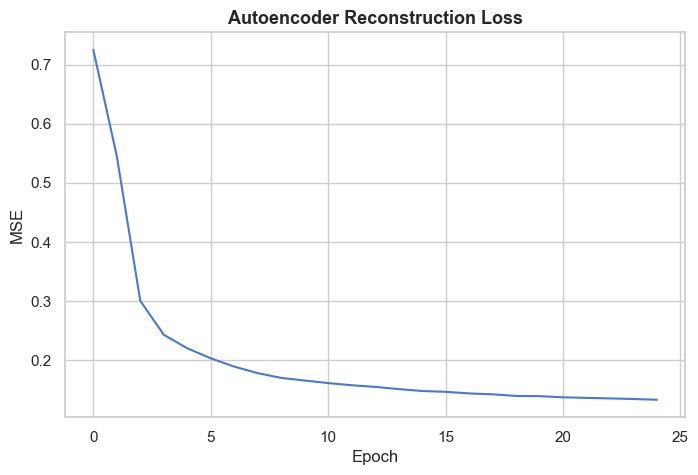

In [302]:
plt.figure(figsize=(8, 5))

plt.plot(recon_history)

plt.title('Autoencoder Reconstruction Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')

plt.show()

In [303]:
ae.eval()

with torch.no_grad():
    Z_pre = ae.encode(
        X_tensor.to(device)
    ).cpu().numpy()

print(Z_pre.shape)

(8949, 4)


In [304]:
latent_kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

latent_labels = latent_kmeans.fit_predict(Z_pre)

latent_silhouette = silhouette_score(
    Z_pre,
    latent_labels
)

print('Latent KMeans Silhouette:', latent_silhouette)

Latent KMeans Silhouette: 0.2921121418476105


In [305]:
class DEC(nn.Module):
    def __init__(self, encoder, n_clusters, latent_dim, alpha=1.0):
        super().__init__()

        self.encoder = encoder
        self.alpha = alpha

        self.cluster_centers = nn.Parameter(
            torch.randn(n_clusters, latent_dim)
        )

    def soft_assign(self, z):
        dist = torch.sum(
            (z.unsqueeze(1) - self.cluster_centers) ** 2,
            dim=2
        )

        q = 1.0 / (1.0 + dist / self.alpha)
        q = q ** ((self.alpha + 1.0) / 2.0)
        q = q / torch.sum(q, dim=1, keepdim=True)

        return q

    def forward(self, x):
        z = self.encoder(x)
        q = self.soft_assign(z)
        return z, q

In [306]:
def target_distribution(q):
    weight = (q ** 2) / torch.sum(q, dim=0)
    return weight / torch.sum(weight, dim=1, keepdim=True)

In [307]:
dec = DEC(
    copy.deepcopy(ae.encoder),
    final_k,
    latent_dim
).to(device)

with torch.no_grad():
    dec.cluster_centers.copy_(
        torch.tensor(
            latent_kmeans.cluster_centers_,
            dtype=torch.float32,
            device=device
        )
    )

In [308]:
indices = torch.arange(len(X_tensor))

dec_loader = DataLoader(
    TensorDataset(X_tensor, indices),
    batch_size=batch_size,
    shuffle=True
)

dec_optimizer = torch.optim.Adam(
    dec.parameters(),
    lr=1e-3
)

dec_epochs = 10
history = []

In [309]:
for epoch in range(dec_epochs):

    dec.eval()

    with torch.no_grad():
        z_all, q_all = dec(
            X_tensor.to(device)
        )

        p_all = target_distribution(q_all)

        preds = torch.argmax(
            q_all,
            dim=1
        ).cpu().numpy()

        sil = silhouette_score(
            z_all.cpu().numpy(),
            preds
        )

    dec.train()

    total_loss = 0
    total = 0

    for xb, idx in dec_loader:
        xb = xb.to(device)

        _, q_batch = dec(xb)

        p_batch = p_all[idx]

        loss = F.kl_div(
            torch.log(q_batch + 1e-10),
            p_batch,
            reduction='batchmean'
        )

        dec_optimizer.zero_grad()
        loss.backward()
        dec_optimizer.step()

        total_loss += loss.item() * xb.size(0)
        total += xb.size(0)

    history.append(sil)

    print(
        f'Epoch {epoch+1}/{dec_epochs} '
        f'Silhouette={sil:.4f}'
    )

Epoch 1/10 Silhouette=0.2921
Epoch 2/10 Silhouette=0.4392
Epoch 3/10 Silhouette=0.5643
Epoch 4/10 Silhouette=0.6259
Epoch 5/10 Silhouette=0.6639
Epoch 6/10 Silhouette=0.6911
Epoch 7/10 Silhouette=0.7135
Epoch 8/10 Silhouette=0.7346
Epoch 9/10 Silhouette=0.7537
Epoch 10/10 Silhouette=0.7709


In [310]:
dec.eval()

with torch.no_grad():
    z_final, q_final = dec(
        X_tensor.to(device)
    )

    dec_labels = torch.argmax(
        q_final,
        dim=1
    ).cpu().numpy()

    Z_final = z_final.cpu().numpy()

In [311]:
dec_silhouette = silhouette_score(
    Z_final,
    dec_labels
)

dec_dbi = davies_bouldin_score(
    Z_final,
    dec_labels
)

dec_ch = calinski_harabasz_score(
    Z_final,
    dec_labels
)

print('DEC Silhouette:', dec_silhouette)
print('DEC DBI:', dec_dbi)
print('DEC CH:', dec_ch)

DEC Silhouette: 0.7839160561561584
DEC DBI: 0.27550827335373756
DEC CH: 59948.80986215037


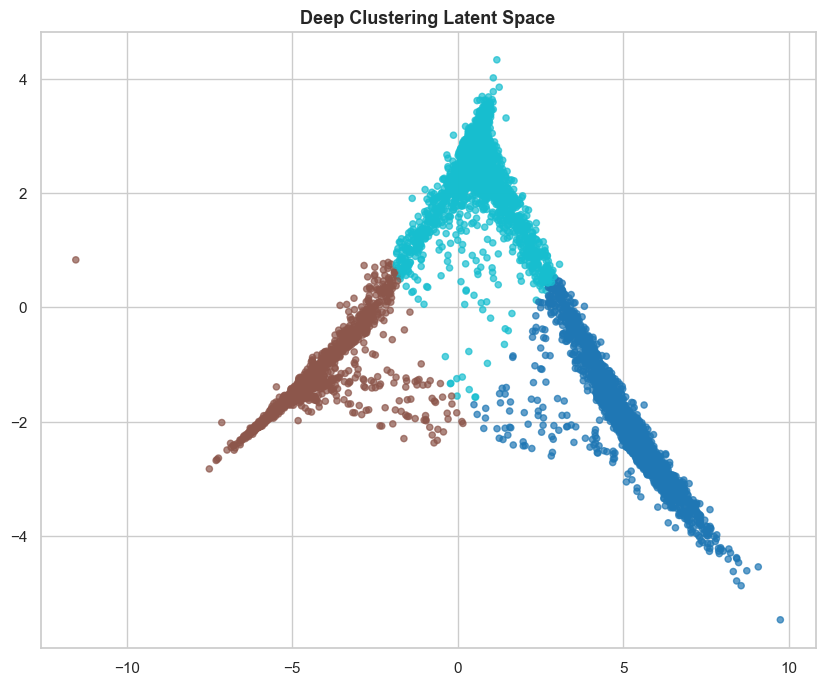

In [312]:
Z_2d = PCA(
    n_components=2,
    random_state=42
).fit_transform(Z_final)

plt.figure(figsize=(10, 8))

plt.scatter(
    Z_2d[:, 0],
    Z_2d[:, 1],
    c=dec_labels,
    cmap='tab10',
    s=20,
    alpha=0.7
)

plt.title('Deep Clustering Latent Space')

plt.show()

In [313]:
comparison_df = pd.DataFrame({
    'Model': [
        'KMeans',
        'DBSCAN',
        'GMM',
        'Latent KMeans',
        'DEC'
    ],
    'Silhouette': [
        baseline_sil,
        db_silhouette,
        gmm_silhouette,
        latent_silhouette,
        dec_silhouette
    ],
    'Davies-Bouldin': [
        np.nan,
        db_dbi,
        gmm_dbi,
        np.nan,
        dec_dbi
    ],
    'Calinski-Harabasz': [
        np.nan,
        db_ch,
        gmm_ch,
        np.nan,
        dec_ch
    ]
})

print(comparison_df)

           Model  Silhouette  Davies-Bouldin  Calinski-Harabasz
0         KMeans    0.259771             NaN                NaN
1         DBSCAN   -0.087120        1.044197         251.200307
2            GMM    0.202356        2.612392        1480.221731
3  Latent KMeans    0.292112             NaN                NaN
4            DEC    0.783916        0.275508       59948.809862


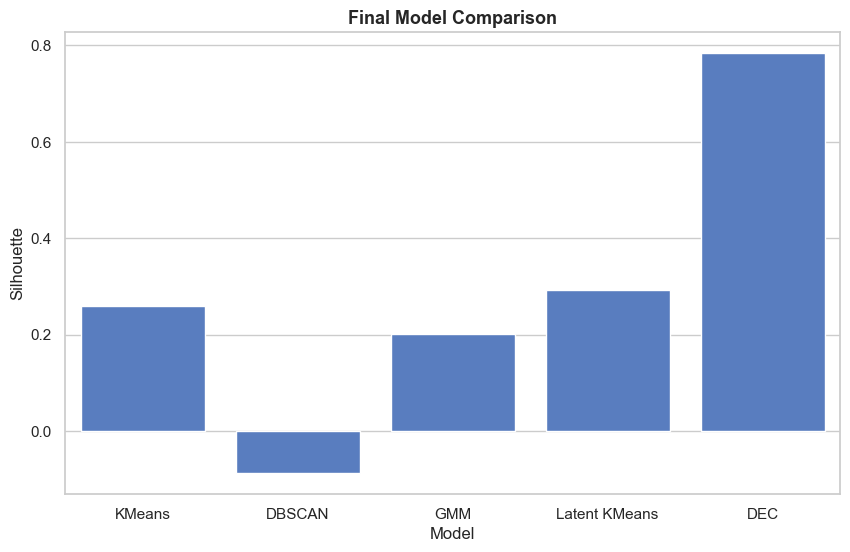

In [314]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x='Model',
    y='Silhouette',
    data=comparison_df
)

plt.title('Final Model Comparison')

plt.show()

In [315]:
final_segments = pd.DataFrame({
    'CUST_ID': df['CUST_ID'],
    'Final_Cluster': dec_labels
})

final_segments.to_csv(
    'final_customer_segments.csv',
    index=False
)

comparison_df.to_csv(
    'evaluation_metrics.csv',
    index=False
)

torch.save(
    dec.state_dict(),
    'dec_model.pth'
)

print('\nDEEP CLUSTERING COMPLETE')


DEEP CLUSTERING COMPLETE
